# Final Year Project: Used Car Price Prediction
**Objective:** To analyze the used car market dataset and build a machine learning model that can predict the selling price of a car based on its features (like age, brand, kilometers driven, etc).

Let's start by importing the necessary libraries for data analysis and visualization.

In [7]:
# Importing basic libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look better
sns.set_style("whitegrid")


## 1. Data Loading and Basic Understanding
First, we will load the dataset and take a look at the first few rows to understand what columns we have.

In [8]:
# Load the dataset
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')

# Let's see how big the dataset is
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Look at the first 5 rows
df.head()

Number of rows: 4340
Number of columns: 8


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [9]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [31]:
df.shape

(3577, 11)

In [10]:
# Check the data types and see if there are any null values right away
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


**Observation:**
It looks like we have 8 columns. The `selling_price` is what we want to predict (our target variable). We have a mix of integer columns (year, selling_price, km_driven) and object/string columns (name, fuel, seller_type, transmission, owner). 

Let's check some basic statistics of the numerical columns.

In [11]:
# Summary statistics for numerical columns
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


## 2. Data Cleaning
Before we can visualize or train a model, we need to clean the data. 

### Checking for Missing Values

In [12]:
# Find out if we have any missing data
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Great! There are no missing values in this dataset.

### Checking for Duplicates
Sometimes the dataset contains duplicate rows. Let's find out.

In [13]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Let's drop these duplicates because they don't add new information
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 763
Shape after dropping duplicates: (3577, 8)


### Feature Engineering (Creating new useful columns)
The `name` column has the full name of the car (e.g., "Maruti 800 AC"). It's too specific. Let's extract just the **Brand** (Maruti) and the **Model**.

Also, the `year` column is just the year of manufacture. A machine learning model understands "Age" better than "Year". So let's calculate the car's age.

In [14]:
# 1. Extract Brand
df['brand'] = df['name'].apply(lambda x: x.split(' ')[0])

# 2. Extract Model (the second and third word)
df['model'] = df['name'].apply(lambda x: ' '.join(x.split(' ')[1:3]) if len(x.split(' ')) > 1 else 'Unknown')

# 3. Calculate Car Age
from datetime import datetime
current_year = datetime.now().year
df['car_age'] = current_year - df['year']

# Now let's see how our dataframe looks
df[['name', 'brand', 'model', 'year', 'car_age']].head()

,name,brand,model,year,car_age
0,Maruti 800 AC,Maruti,800 AC,2007,19
1,Maruti Wagon R LXI Minor,Maruti,Wagon R,2007,19
2,Hyundai Verna 1.6 SX,Hyundai,Verna 1.6,2012,14
3,Datsun RediGO T Option,Datsun,RediGO T,2017,9
4,Honda Amaze VX i-DTEC,Honda,Amaze VX,2014,12


We don't need the original `name` and `year` columns anymore since we extracted the useful parts. Let's drop them to keep things clean.

In [15]:
# Drop unnecessary columns
df_clean = df.drop(['name', 'year'], axis=1)
df_clean.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,model,car_age
0,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,800 AC,19
1,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,Wagon R,19
2,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,Verna 1.6,14
3,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,RediGO T,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,Amaze VX,12


## 3. Exploratory Data Analysis (EDA)
Now that our data is clean, let's explore it to find patterns. Visualizations help us understand the relationships between different features and the selling price.

### 3.1 Analyzing the Target Variable (Selling Price)

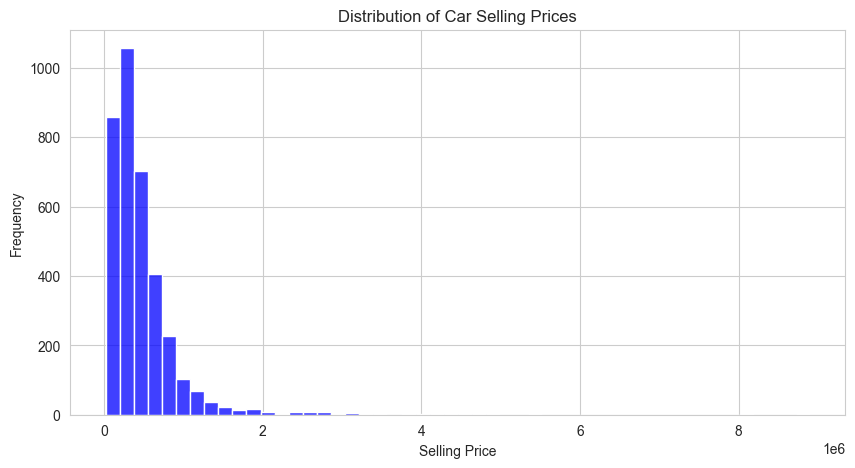

In [16]:
# Let's look at the distribution of selling prices
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['selling_price'], bins=50, color='blue')
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

**Insight:** The selling price is highly right-skewed. Most cars are sold at lower prices (budget segment), and there are a few very expensive luxury cars. 

Let's check for extreme outliers using a boxplot.

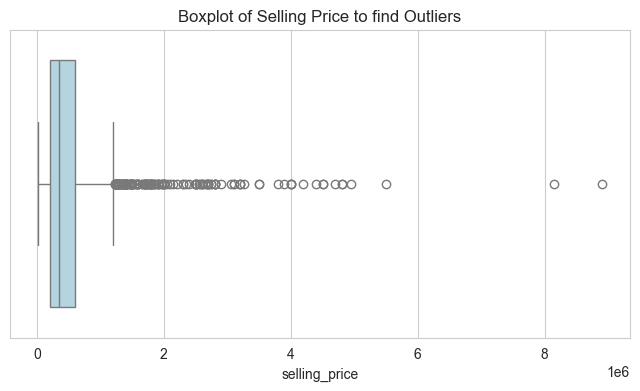

In [17]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['selling_price'], color='lightblue')
plt.title('Boxplot of Selling Price to find Outliers')
plt.show()

Since we have some crazy outliers, let's cap the selling price at the 99th percentile so our model doesn't get confused by 1 or 2 extremely expensive cars.

In [18]:
# Cap selling price
price_cap = df_clean['selling_price'].quantile(0.99)
df_clean['selling_price'] = np.where(df_clean['selling_price'] > price_cap, price_cap, df_clean['selling_price'])

print("Capped max price at:", price_cap)

Capped max price at: 2675000.0


### 3.2 Categorical Features Analysis
Let's see how things like Fuel Type and Transmission affect the price.

C:\Users\dhruv\AppData\Local\Temp\ipykernel_23136\4224418103.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='fuel', y='selling_price', data=df_clean, ci=None)


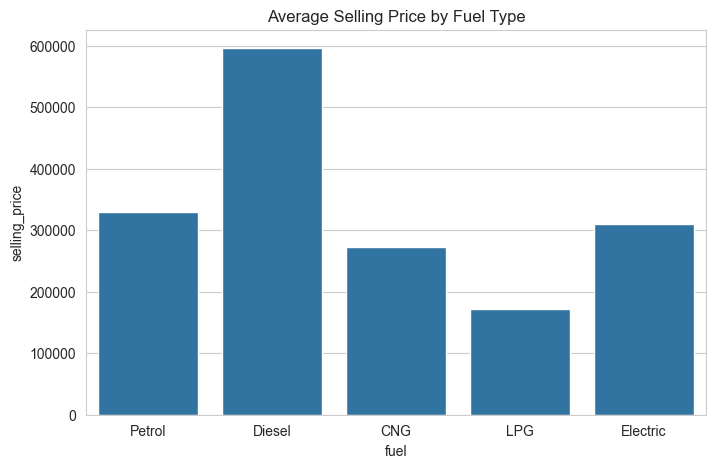

In [19]:
# Average price by Fuel Type
plt.figure(figsize=(8, 5))
sns.barplot(x='fuel', y='selling_price', data=df_clean, ci=None)
plt.title('Average Selling Price by Fuel Type')
plt.show()

**Insight:** Diesel cars generally sell for much higher prices compared to Petrol or CNG cars.

C:\Users\dhruv\AppData\Local\Temp\ipykernel_23136\3722458522.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='transmission', y='selling_price', data=df_clean, ci=None)


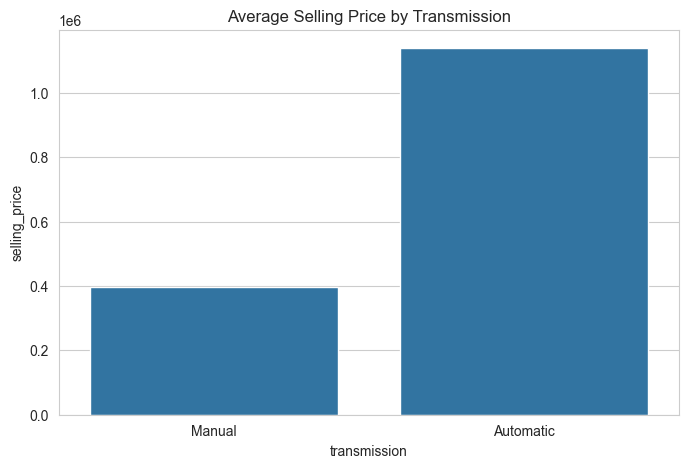

In [20]:
# Average price by Transmission
plt.figure(figsize=(8, 5))
sns.barplot(x='transmission', y='selling_price', data=df_clean, ci=None)
plt.title('Average Selling Price by Transmission')
plt.show()

**Insight:** Automatic cars are significantly more expensive than manual cars. This is a very important feature for our model.
             
Let's also look at how the number of previous owners affects the price.

C:\Users\dhruv\AppData\Local\Temp\ipykernel_23136\4209066236.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='owner', y='selling_price', data=owner_data, order=owner_order, ci=None, palette="viridis")
C:\Users\dhruv\AppData\Local\Temp\ipykernel_23136\4209066236.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='owner', y='selling_price', data=owner_data, order=owner_order, ci=None, palette="viridis")


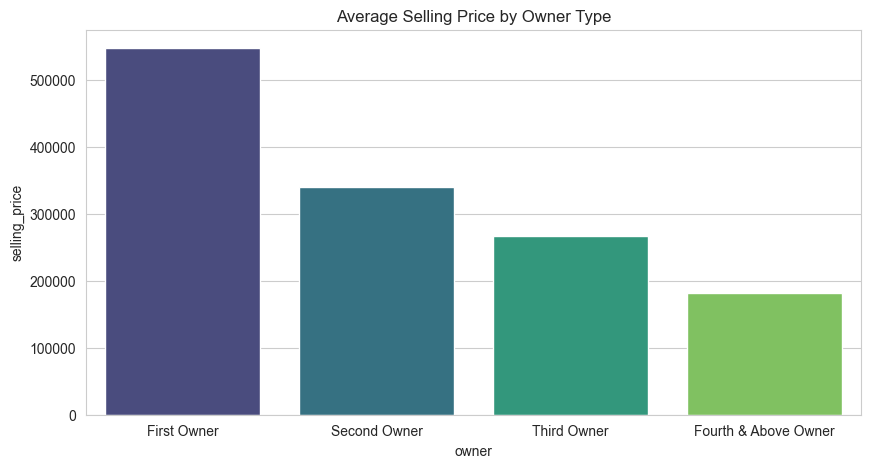

In [21]:
# Average price by Owner Type
plt.figure(figsize=(10, 5))
owner_order = ["First Owner", "Second Owner", "Third Owner", "Fourth & Above Owner"]
owner_data = df_clean[df_clean['owner'] != 'Test Drive Car']
sns.barplot(x='owner', y='selling_price', data=owner_data, order=owner_order, ci=None, palette="viridis")
plt.title('Average Selling Price by Owner Type')
plt.show()

**Insight:** As expected, First Owner cars have the highest resale value, and the value drops sequentially for second and third owners.

### 3.3 Market Supply Analysis
Let's quickly see which car brands are the most common in our dataset.

C:\Users\dhruv\AppData\Local\Temp\ipykernel_23136\1088886467.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette="Blues_r")


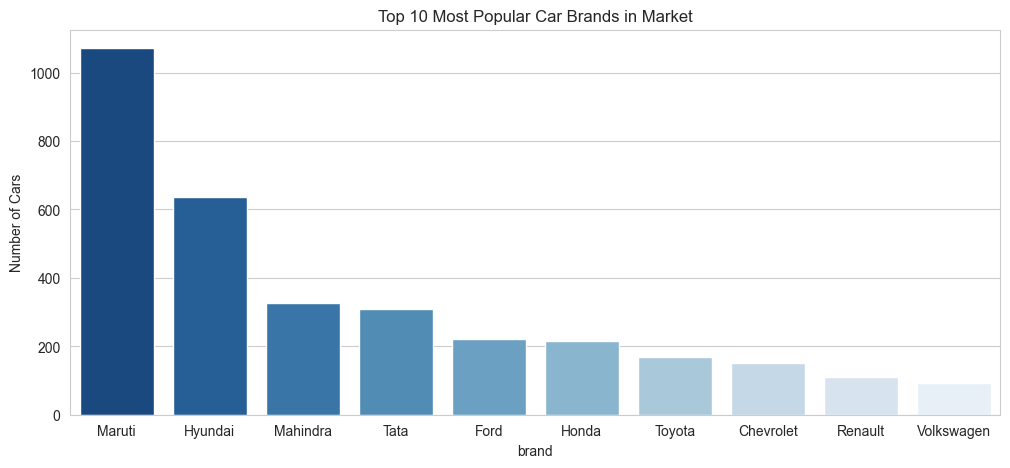

In [22]:
# Top 10 most common brands
plt.figure(figsize=(12, 5))
top_brands = df_clean['brand'].value_counts().head(10)
sns.barplot(x=top_brands.index, y=top_brands.values, palette="Blues_r")
plt.title('Top 10 Most Popular Car Brands in Market')
plt.ylabel('Number of Cars')
plt.show()

### 3.4 Numerical Features Analysis
Let's see how the age of the car and kilometers driven affect the price. We expect older cars to be cheaper.

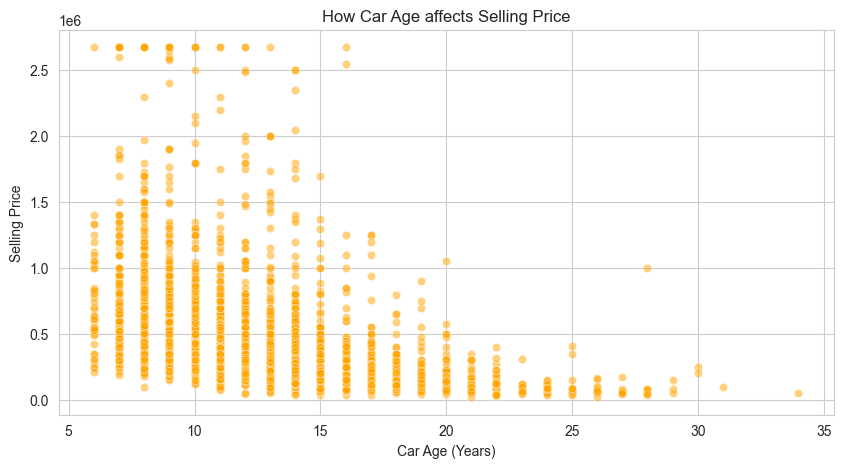

In [23]:
# Selling Price vs Car Age
plt.figure(figsize=(10, 5))
sns.scatterplot(x='car_age', y='selling_price', data=df_clean, alpha=0.5, color='orange')
plt.title('How Car Age affects Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.show()

**Insight:** There is a clear negative correlation. As the car age increases, the selling price drops rapidly.

Let's also look at Kilometers Driven. There are probably some outliers here too.

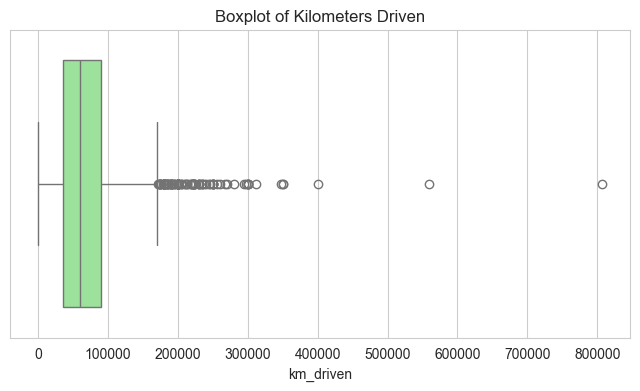

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['km_driven'], color='lightgreen')
plt.title('Boxplot of Kilometers Driven')
plt.show()

# Let's cap the km_driven at 500,000 to handle those weird outliers
df_clean['km_driven_cap'] = df_clean['km_driven'].apply(lambda x: min(x, 500000))
df_clean = df_clean.drop('km_driven', axis=1)

## 4. Preparing Data for Machine Learning
Machine Learning models only understand numbers. We have text columns (like brand, fuel, transmission) that we need to convert to numbers. 

We will use Scikit-Learn's `ColumnTransformer` to handle this. It will automatically apply `OneHotEncoder` to the text columns and `StandardScaler` to the number columns.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separate the target variable (what we want to predict) from the features
X = df_clean.drop('selling_price', axis=1)
y = df_clean['selling_price']

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2861, 8)
Testing data shape: (716, 8)


In [26]:
# Setup the preprocessing pipeline
numeric_features = ['car_age', 'km_driven_cap']
categorical_features = ['fuel', 'seller_type', 'transmission', 'owner', 'brand', 'model']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

## 5. Training Machine Learning Models
We will try three different algorithms:
1. Linear Regression (Simple baseline)
2. Decision Tree (Better for complex data)
3. Random Forest (An ensemble method, usually the best)

We will use a `Pipeline` to tie the preprocessor and the model together neatly.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# -------------------------
# MODEL 1: Linear Regression
# -------------------------
print("Training Linear Regression...")
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Linear Regression R2 Score:", r2_score(y_test, lr_preds))
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_preds))

Training Linear Regression...
Linear Regression R2 Score: 0.8410241574204371
Linear Regression MAE: 98654.18744452336


In [28]:
from sklearn.tree import DecisionTreeRegressor

# -------------------------
# MODEL 2: Decision Tree
# -------------------------
print("Training Decision Tree...")
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print("Decision Tree R2 Score:", r2_score(y_test, dt_preds))
print("Decision Tree MAE:", mean_absolute_error(y_test, dt_preds))

Training Decision Tree...
Decision Tree R2 Score: 0.648787787267449
Decision Tree MAE: 131893.02583798883


In [32]:
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# MODEL 3: Random Forest
# -------------------------
print("Training Random Forest...")
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, rf_preds))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_preds))

Training Random Forest...
Random Forest R2 Score: 0.7736543086398898
Random Forest MAE: 109772.64486840472


In [49]:
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# MODEL 3: Tuned Random Forest
# -------------------------
print("Training Random Forest...")

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='log2',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, rf_preds))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_preds))

Training Random Forest...
Random Forest R2 Score: 0.7958904726707106
Random Forest MAE: 108312.7051813869


In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', None]
}

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
pred = best_model.predict(X_test)

print("Best Params:", search.best_params_)
print("Random Forest R2 Score:", r2_score(y_test, pred))
print("Random Forest MAE:", mean_absolute_error(y_test, pred))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Params: {'regressor__n_estimators': 500, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 'log2', 'regressor__max_depth': None}
Random Forest R2 Score: 0.7974539140611916
Random Forest MAE: 107775.89925242528


## 6. Conclusion and Saving the Final Model
As we can see from the R2 scores, the **Random Forest** model performs the best by far. It understands the complex relationships between the car's features much better than a simple straight line (Linear Regression).

We will now save this Random Forest pipeline as a `.pkl` file. Our FastAPI backend will load this file to make live predictions when users visit our web app!

In [30]:
import pickle

# We will save the rf_model pipeline
with open('car_price_rf_pipeline.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("Success! The Random Forest model has been saved as 'car_price_rf_pipeline.pkl'.")

Success! The Random Forest model has been saved as 'car_price_rf_pipeline.pkl'.
